# VAE inpainting training


In [1]:
!nvidia-smi

Thu Apr 23 22:00:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   48C    P0             59W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Clone repo and install

In [3]:
%cd /content
!git clone https://github.com/Mcfish99/Intro-to-Deep-Learning-Final-Project.git
%cd Intro-to-Deep-Learning-Final-Project
!git pull

/content
Cloning into 'Intro-to-Deep-Learning-Final-Project'...
remote: Enumerating objects: 6098, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 6098 (delta 7), reused 18 (delta 6), pack-reused 6078 (from 2)
Receiving objects: 100% (6098/6098), 558.50 MiB | 9.50 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Updating files: 100% (6026/6026), done.
/content/Intro-to-Deep-Learning-Final-Project
Already up to date.


In [4]:
!pip install -q -r requirements.txt
!pip install -q "numpy<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 131.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requ

In [7]:
import torch
print(torch.__version__)
print(torch.cuda.get_device_name(0))

2.10.0+cu128
NVIDIA A100-SXM4-80GB


In [5]:
import torch
print(torch.__version__)
print(torch.cuda.get_device_name(0))
print(f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB VRAM")

2.10.0+cu128
NVIDIA A100-SXM4-80GB
85 GB VRAM


### Dataset

Copy from Drive to the local SSD. Training off Drive directly is painfully slow.

In [8]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_e5685fb040a8e08e06898d85695d2f56'

!pip install -q kaggle

!kaggle datasets list | head -5

ref                                                         title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                              Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          11015        241                1  
nalisha/job-salary-prediction-dataset                       Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          14958        330                1  
rosemeenshaikh/op-rated-tv-shows-from-tmdb                  Top Rated TV Shows from TMDB                            335625  2026-04-20 09:10:56.430000            604         27                1  


In [9]:
!mkdir -p /content/data
!kaggle datasets download -d badasstechie/celebahq-resized-256x256 -p /content/data --unzip
!ls /content/data/

Dataset URL: https://www.kaggle.com/datasets/badasstechie/celebahq-resized-256x256
License(s): GPL-2.0
100% 283M/283M [00:18<00:00, 15.9MB/s]

celeba_hq_256


In [10]:
import os

DATA_DIR = "/content/data/celeba_hq_256"

if not os.path.exists(DATA_DIR):
    !mkdir -p /content/data
    !cp -r {DRIVE_DATA} /content/data/

n = len([f for f in os.listdir(DATA_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"{n} images")

30000 images


In [11]:
import os, shutil, glob

TEST_SUBSET = "/content/test_subset"
os.makedirs(TEST_SUBSET, exist_ok=True)

for src in sorted(glob.glob(f"{DATA_DIR}/*.jpg") + glob.glob(f"{DATA_DIR}/*.png"))[:16]:
    dst = os.path.join(TEST_SUBSET, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print(f"{len(os.listdir(TEST_SUBSET))} images")

16 images


In [12]:
!python -m src.VAE.train \
    --data-dir /content/test_subset \
    --output-dir /tmp/vae_overfit \
    --overfit --overfit-steps 200 \
    --batch-size 8 \
    --log-every 20

[train] device: cuda
[train] dataset size: 16
[train] params: 29.7M
[train] saved checkpoint for epoch 0
[train] saved checkpoint for epoch 1
[train] saved checkpoint for epoch 2
[train] saved checkpoint for epoch 3
[train] saved checkpoint for epoch 4
[train] saved checkpoint for epoch 5
[train] saved checkpoint for epoch 6
[train] saved checkpoint for epoch 7
[train] saved checkpoint for epoch 8
[ep   9 | step     20 |   13.1s] loss=2.6805 hole=0.3938 kl=9.84
[train] saved checkpoint for epoch 9
[train] saved checkpoint for epoch 10
[train] saved checkpoint for epoch 11
[train] saved checkpoint for epoch 12
[train] saved checkpoint for epoch 13
[train] saved checkpoint for epoch 14
[train] saved checkpoint for epoch 15
[train] saved checkpoint for epoch 16
[train] saved checkpoint for epoch 17
[train] saved checkpoint for epoch 18
[ep  19 | step     40 |   25.7s] loss=2.0613 hole=0.3083 kl=3.65
[train] saved checkpoint for epoch 19
[train] saved checkpoint for epoch 20
[train] saved 

### Training

In [13]:
# Save to Drive so checkpoints survive disconnects
CKPT_DIR = "/content/drive/MyDrive/inpainting_checkpoints/vae"
!mkdir -p {CKPT_DIR}

In [14]:
!python -m src.VAE.train \
    --data-dir {DATA_DIR} \
    --output-dir {CKPT_DIR} \
    --epochs 30 \
    --batch-size 32 \
    --num-workers 8 \
    --image-size 256 \
    --lr 2e-4 \
    --beta-kl 0.01 \
    --lambda-perc 0.1 \
    --log-every 100

[train] device: cuda
[train] dataset size: 30000
[train] params: 29.7M
[train] using VGG perceptual loss
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:02<00:00, 242MB/s]
[ep   0 | step    100 |   12.9s] loss=1.8052 hole=0.2809 kl=2.34 perc=0.5939
[ep   0 | step    200 |   24.7s] loss=1.5368 hole=0.2416 kl=0.82 perc=0.5640
[ep   0 | step    300 |   36.4s] loss=1.4848 hole=0.2329 kl=0.75 perc=0.3972
[ep   0 | step    400 |   48.2s] loss=1.4702 hole=0.2283 kl=0.92 perc=0.4268
[ep   0 | step    500 |   60.0s] loss=1.2640 hole=0.1977 kl=0.66 perc=0.4329
[ep   0 | step    600 |   71.8s] loss=1.3884 hole=0.2220 kl=0.92 perc=0.4408
[ep   0 | step    700 |   83.6s] loss=1.4138 hole=0.2257 kl=1.10 perc=0.4992
[ep   0 | step    800 |   95.4s] loss=1.2152 hole=0.1931 kl=0.34 perc=0.4574
[ep   0 | step    900 |  107.2s] loss=1.4559 hole=0.2226 kl=0.43 perc=0.4020
[train] saved checkpoint for epoch 0


To keep Colab from disconnecting on idle, open browser devtools (F12) and paste into the console:

```js
setInterval(() => document.querySelector("colab-connect-button")?.shadowRoot?.querySelector("#connect")?.click(), 60000);
```

### Peek at samples during training

30 epochs saved


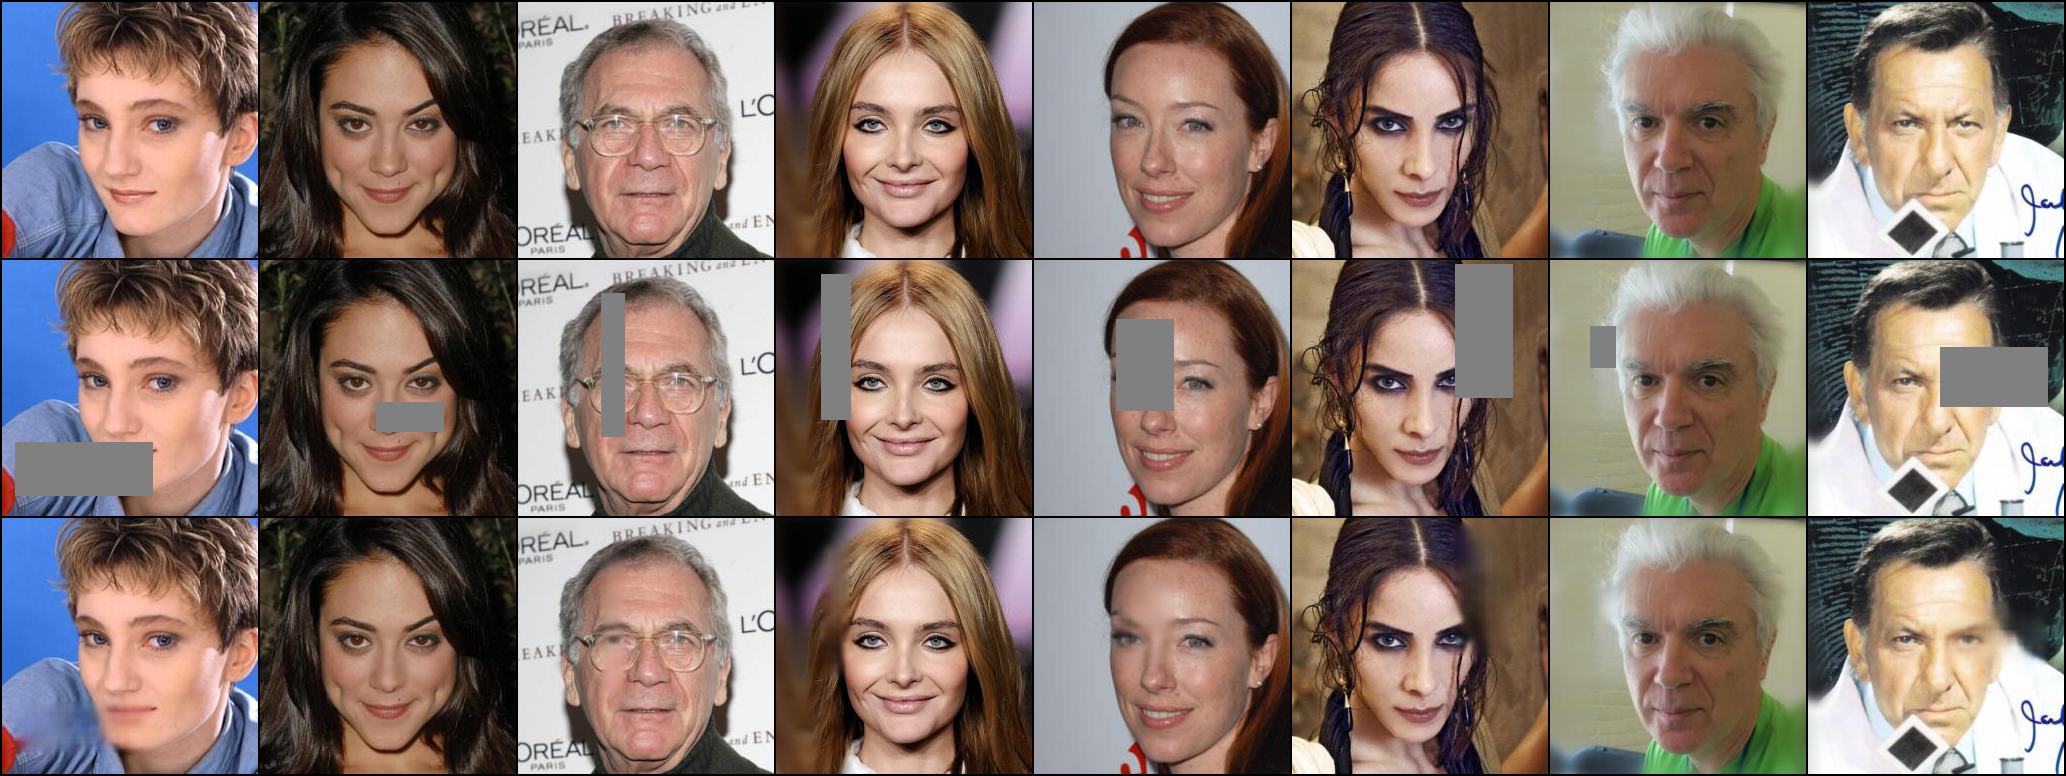

In [15]:
from IPython.display import Image, display
import glob

samples = sorted(glob.glob(f"{CKPT_DIR}/samples/*.png"))
print(f"{len(samples)} epochs saved")
if samples:
    display(Image(samples[-1]))

In [17]:
!ls /content/drive/MyDrive/inpainting_checkpoints/vae/

samples		  vae_epoch_007.pt  vae_epoch_015.pt  vae_epoch_023.pt
vae_epoch_000.pt  vae_epoch_008.pt  vae_epoch_016.pt  vae_epoch_024.pt
vae_epoch_001.pt  vae_epoch_009.pt  vae_epoch_017.pt  vae_epoch_025.pt
vae_epoch_002.pt  vae_epoch_010.pt  vae_epoch_018.pt  vae_epoch_026.pt
vae_epoch_003.pt  vae_epoch_011.pt  vae_epoch_019.pt  vae_epoch_027.pt
vae_epoch_004.pt  vae_epoch_012.pt  vae_epoch_020.pt  vae_epoch_028.pt
vae_epoch_005.pt  vae_epoch_013.pt  vae_epoch_021.pt  vae_epoch_029.pt
vae_epoch_006.pt  vae_epoch_014.pt  vae_epoch_022.pt  vae_latest.pt


In [20]:
!pip install -q "numpy>=2.0,<2.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 113.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [1]:
# 1. mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

%cd /content/Intro-to-Deep-Learning-Final-Project

/content/Intro-to-Deep-Learning-Final-Project


In [3]:

import numpy
print(numpy.__version__)

2.2.6


In [4]:

DATA_DIR = "/content/data/celeba_hq_256"
CKPT_DIR = "/content/drive/MyDrive/inpainting_checkpoints/vae"

import os
print(f"Data: {len(os.listdir(DATA_DIR)) if os.path.exists(DATA_DIR) else 'GONE'}")
print(f"Checkpoints: {os.listdir(CKPT_DIR) if os.path.exists(CKPT_DIR) else 'GONE'}")

Data: 30000
Checkpoints: ['samples', 'vae_epoch_000.pt', 'vae_latest.pt', 'vae_epoch_001.pt', 'vae_epoch_002.pt', 'vae_epoch_003.pt', 'vae_epoch_004.pt', 'vae_epoch_005.pt', 'vae_epoch_006.pt', 'vae_epoch_007.pt', 'vae_epoch_008.pt', 'vae_epoch_009.pt', 'vae_epoch_010.pt', 'vae_epoch_011.pt', 'vae_epoch_012.pt', 'vae_epoch_013.pt', 'vae_epoch_014.pt', 'vae_epoch_015.pt', 'vae_epoch_016.pt', 'vae_epoch_017.pt', 'vae_epoch_018.pt', 'vae_epoch_019.pt', 'vae_epoch_020.pt', 'vae_epoch_021.pt', 'vae_epoch_022.pt', 'vae_epoch_023.pt', 'vae_epoch_024.pt', 'vae_epoch_025.pt', 'vae_epoch_026.pt', 'vae_epoch_027.pt', 'vae_epoch_028.pt', 'vae_epoch_029.pt']


### Visualize results across mask sizes

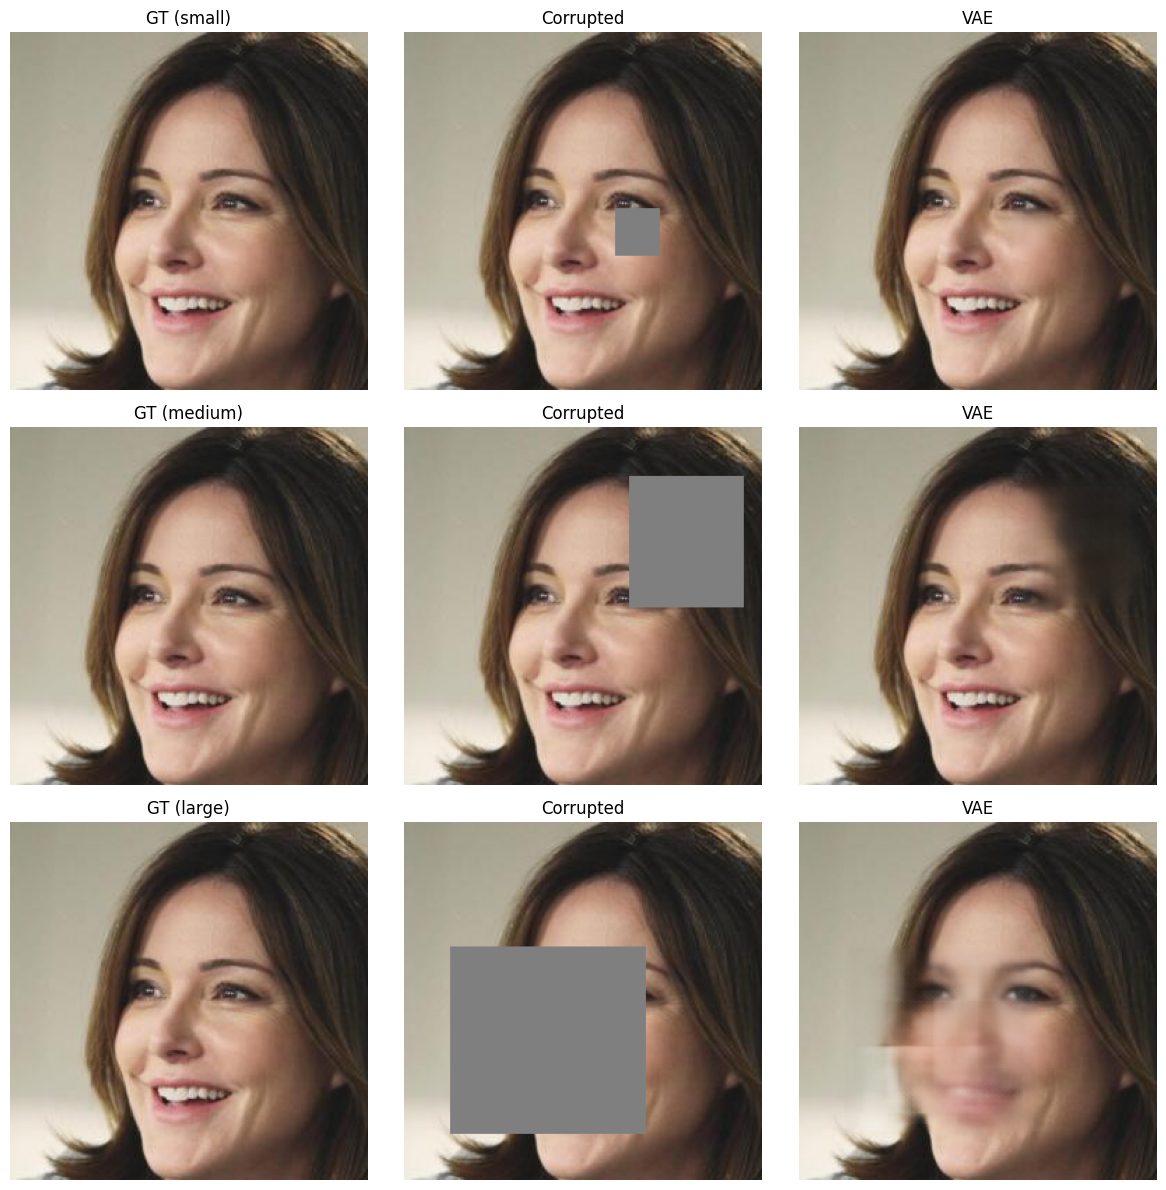

In [5]:
import sys
sys.path.insert(0, "/content/Intro-to-Deep-Learning-Final-Project")

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src.VAE.inpainter import VAEInpainter
from src.shared.dataset import CelebAHQDataset
from src.shared.mask import batch_masks

vae = VAEInpainter(ckpt_path=f"{CKPT_DIR}/vae_latest.pt", device="cuda")

ds = CelebAHQDataset(DATA_DIR, image_size=256)
x = next(iter(DataLoader(ds, batch_size=4, shuffle=True))).cuda()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for r, regime in enumerate(["small", "medium", "large"]):
    mask = batch_masks(x.size(0), 256, 256, condition=regime).cuda()
    y = x * (1 - mask)
    xh = vae.inpaint(y, mask)
    for c, (img, t) in enumerate([(x[0], f"GT ({regime})"), (y[0], "Corrupted"), (xh[0], "VAE")]):
        axes[r, c].imshow(((img.detach().cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0))
        axes[r, c].set_title(t); axes[r, c].axis("off")

plt.tight_layout(); plt.show()

### Diverse completions

Same corrupted input, different plausible outputs — VAE can do this, deterministic methods can't. Good figure for the report.

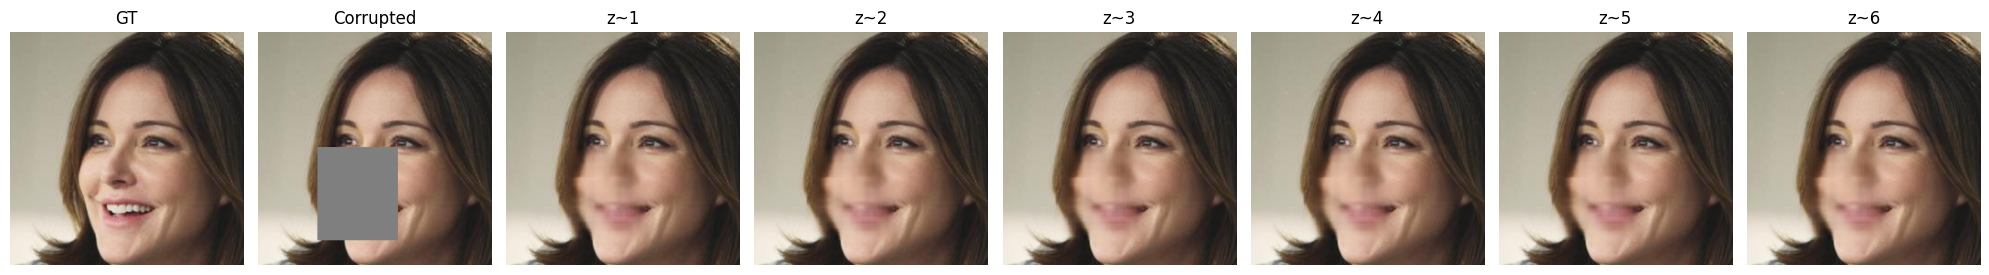

In [6]:
x_one = x[:1]
mask_one = batch_masks(1, 256, 256, condition="medium").cuda()
y_one = x_one * (1 - mask_one)

samples = vae.sample_diverse(y_one, mask_one, n_samples=6)

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
axes[0].imshow(((x_one[0].detach().cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0))
axes[0].set_title("GT"); axes[0].axis("off")
axes[1].imshow(((y_one[0].detach().cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0))
axes[1].set_title("Corrupted"); axes[1].axis("off")
for i, s in enumerate(samples):
    axes[i+2].imshow(((s[0].detach().cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0))
    axes[i+2].set_title(f"z~{i+1}"); axes[i+2].axis("off")

plt.tight_layout(); plt.show()

In [7]:
import os
from IPython.display import Image, display


FIGURES_DIR = "/content/drive/MyDrive/inpainting_checkpoints/vae/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)
